# MULTI workspace coverage vs. control evaluation (Comment 7, MULTI half)

Companion to `SINGLE_workspace_coverage.ipynb`. Training-workspace bending
angle comes directly from the stored per-section curvature labels. The
20-target control-evaluation bending angle reuses the PCC-consistent tendon
configurations already computed by the null-space-ablation replay
(`MULTI_nullspace_ablation.py`) rather than re-deriving them. The tracked
trajectories use the data-driven IK network as a fast approximate inverse
-- a coverage *characterization*, not a controller comparison, so this is a
much lower-stakes use of the network than the null-space ablation was.

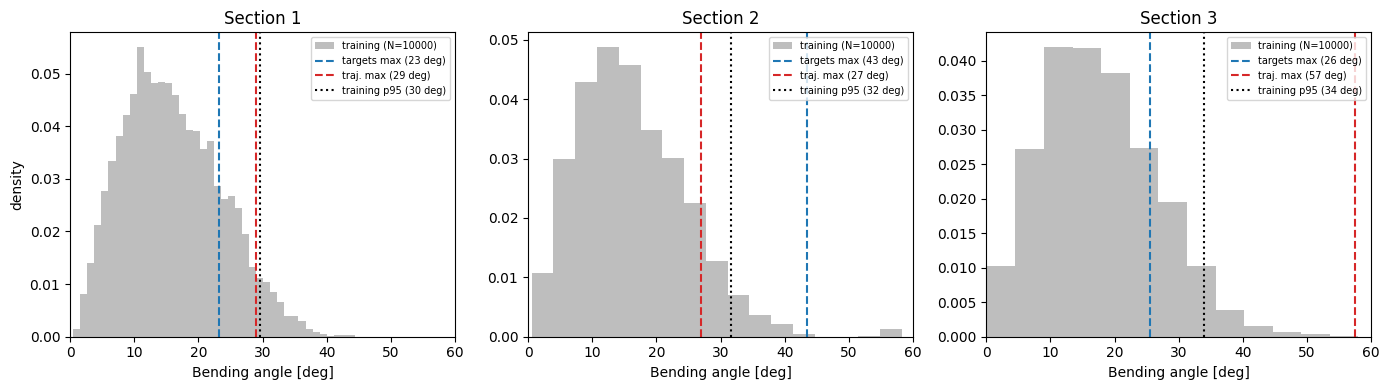

In [1]:

import numpy as np
import matplotlib.pyplot as plt

d = np.load("results/MULTI_workspace_coverage.npz")
theta_train, theta_targets, theta_traj = d["theta_train"], d["theta_targets"], d["theta_traj"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for sec in range(3):
    ax = axes[sec]
    ax.hist(theta_train[:, sec], bins=40, density=True, alpha=0.5, color="#7f7f7f",
            label=f"training (N={len(theta_train)})")
    ax.axvline(theta_targets[:, sec].max(), color="#1f77b4", ls="--",
               label=f"targets max ({theta_targets[:,sec].max():.0f} deg)")
    ax.axvline(theta_traj[:, sec].max(), color="#d62728", ls="--",
               label=f"traj. max ({theta_traj[:,sec].max():.0f} deg)")
    ax.axvline(np.percentile(theta_train[:, sec], 95), color="k", ls=":",
               label=f"training p95 ({np.percentile(theta_train[:,sec],95):.0f} deg)")
    ax.set_xlim(0, 60)
    ax.set_title(f"Section {sec+1}")
    ax.set_xlabel("Bending angle [deg]")
    ax.legend(fontsize=7)
axes[0].set_ylabel("density")
plt.tight_layout()
plt.savefig("results/multi_workspace_coverage.pdf")
plt.show()


**Note on the training-workspace max**: the polynomial-fit max is unreliable
for MULTI sections II/III (occasional degenerate fits, up to 136-178 deg --
physically implausible), so the plot above caps the x-axis at 60 deg and
uses p95 as the trustworthy training-range reference rather than max,
consistent with how this is handled elsewhere in this analysis.

In [2]:

for sec in range(3):
    t_tr, t_tg, t_trj = theta_train[:,sec], theta_targets[:,sec], theta_traj[:,sec]
    p95 = np.percentile(t_tr, 95)
    print(f"Section {sec+1}: targets max {t_tg.max():.1f} deg = {100*t_tg.max()/p95:.0f}% of training p95 ({p95:.1f} deg)")
    print(f"             trajectories max {t_trj.max():.1f} deg = {100*t_trj.max()/p95:.0f}% of training p95")


Section 1: targets max 23.1 deg = 78% of training p95 (29.7 deg)
             trajectories max 29.0 deg = 98% of training p95
Section 2: targets max 43.4 deg = 137% of training p95 (31.7 deg)
             trajectories max 27.0 deg = 85% of training p95
Section 3: targets max 25.5 deg = 75% of training p95 (34.0 deg)
             trajectories max 57.4 deg = 169% of training p95
